In [10]:
import earthaccess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker,colors
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from scipy import stats
import math
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime,date, timedelta
import datetime as dt 
import cmocean as cmoc
import cmocean.cm as cmo
from erddapy import ERDDAP
import time
import requests
from scipy import stats, odr
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import re
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import os
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import ast
import matplotlib.gridspec as gridspec
import hvplot.xarray
#import holoviews as hv
import hvplot.pandas
import geoviews as gv
from bokeh.models import HoverTool
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
#import contextily as ctx
import xarray.ufuncs as xu
import matplotlib.ticker as mticker
import cblind as cblind
from datetime import date, time, datetime
import seaborn as sns

In [11]:
#load in the data
seamap_df = pd.read_csv('https://raw.githubusercontent.com/fish-pace/fish-pace-datasets/main/datasets/SEAMAP/data/seamap_with_species.csv',
                       parse_dates=['Loc_date'])

Text(0.5, 1.0, 'seamap Hypoxia: Station Locations')

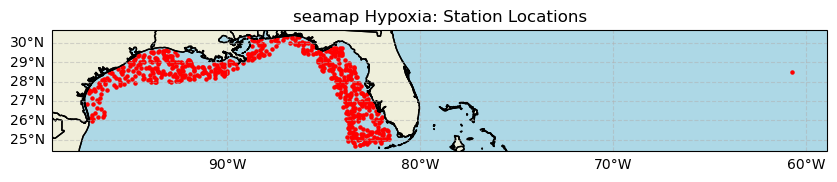

In [12]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)
ax.scatter(seamap_df['Longitude'], seamap_df['Latitude'], color='red', s=5, marker='o')
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax.set_title('seamap Hypoxia: Station Locations')

In [13]:
seamap_df=seamap_df[['Loc_date','Latitude','Longitude','DEPTH_SSTA','DEPTH_EMID','DEPTH_EMAX','TEMPSURF','TEMPMID','TEMPMAX',
                     'SALSURF','SALMID','SALMAX','CHLORSURF','CHLORMID','CHLORMAX','OXYSURF','OXYMID','OXYMAX']]
#rename for easier understanding (NOTE DEPTH SSTA is not surface depth, this csv files does not have surface depth so need to approximate 
seamap_rename = seamap_df.rename(columns={"DEPTH_SSTA": "depth_min", "DEPTH_EMID": "depth_mid","DEPTH_EMAX":"depth_max",
                                         "TEMPSURF": "temp_min", "TEMPMID": "temp_mid","TEMPMAX":"temp_max",
                                         "SALSURF": "sal_min", "SALMID": "sal_mid","SALMAX":"sal_max",
                                         "CHLORSURF": "chl_min", "CHLORMID": "chl_mid","CHLORMAX":"chl_max",
                                         "OXYSURF": "oxy_min", "OXYMID": "oxy_mid","OXYMAX":"oxy_max"}).reset_index(drop=True)


In [14]:
seamap_rename['row_id'] = seamap_rename.index
stubs = ['depth', 'temp', 'sal', 'chl', 'oxy']
#turn into dataframe with 1 depth, 1 temp, ect. 
df_long = pd.wide_to_long(seamap_rename,stubnames=stubs, i=['row_id','Loc_date', 'Latitude', 'Longitude'], # The columns that stay constant
    j='level', sep='_',   suffix='\w+')
df_long = df_long.reset_index()
df_long = df_long.drop(columns=['row_id'])

<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\w'
C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_14680\2791144446.py:5: SyntaxWarning: invalid escape sequence '\w'
  j='level', sep='_',   suffix='\w+')


In [15]:
#SINCE this dataset doesn't seem to have a surface depth (WHY IDK), just assume depth = 0 at surface so need to replace min depths w 1
df_long.loc[df_long['level'] == 'min', 'depth'] = 0

In [16]:
#calculate stability
import gsw

def add_turner_angle(group):
    # 1. Ensure the profile is sorted by depth (surface to deep)
    group = group.sort_values('depth')
    sal = group['sal'].values
    temp = group['temp'].values
    depth = group['depth'].values
    
    results = gsw.stability.Turner_Rsubrho(sal, temp, depth)
    tu = results[0] 
    
    # 4. Handle the shape mismatch
    # If inputs are length 3 (min, mid, max), output is length 2.
    # We prepend NaN to the first depth (min) to align the columns.
    if len(tu) == len(depth) - 1:
        tu = np.insert(tu, 0, np.nan)
    elif len(tu) != len(depth):
        # Fallback if dimensions are unexpected
        tu = np.full(len(depth), np.nan)

    group['tu'] = tu
    return group

df_long = df_long.groupby(['Loc_date', 'Latitude', 'Longitude']).apply(add_turner_angle)

df_long = df_long.reset_index(drop=True)

#print(df_long[['Loc_date', 'depth', 'level', 'tu']].head(6))

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_14680\2471485360.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_long = df_long.groupby(['Loc_date', 'Latitude', 'Longitude']).apply(add_turner_angle)


Text(-1.1693705988362009, 119.9, 'Diffusive')

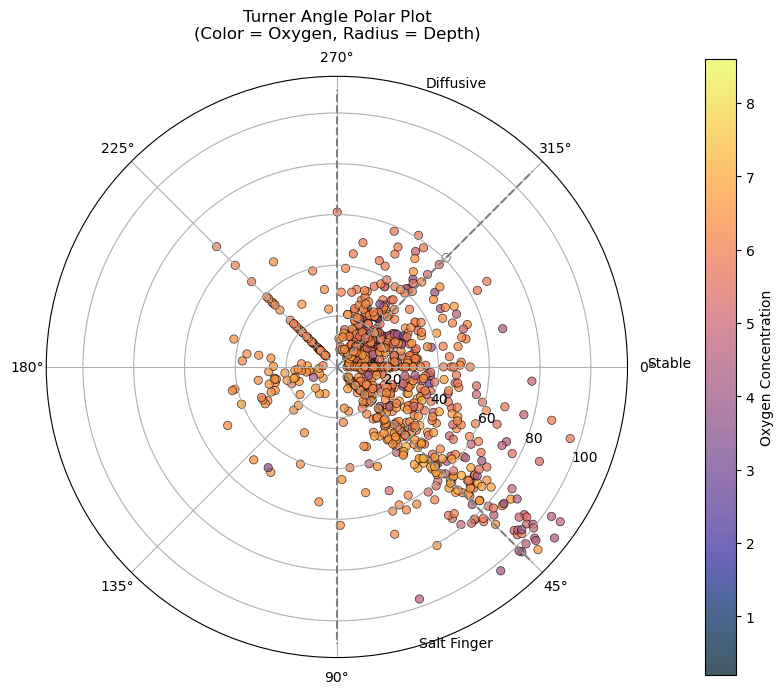

In [17]:
plot_data = df_long.dropna(subset=['tu']).copy()
plot_data['tu_rad'] = np.radians(plot_data['tu'])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')
sc = ax.scatter(x=plot_data['tu_rad'], y=plot_data['depth'], c=plot_data['oxy'], 
    cmap=cmo.thermal, alpha=0.75, edgecolors='k',  linewidth=0.5)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Oxygen Concentration')
ax.set_title("Turner Angle Polar Plot\n(Color = Oxygen, Radius = Depth)", va='bottom')

ax.set_theta_zero_location("E")
ax.set_theta_direction(-1) # Clockwise
ax.vlines(np.radians([45, 90, -45, -90]), 0, plot_data['depth'].max(), colors='gray', linestyles='--')
ax.text(np.radians(0), plot_data['depth'].max()*1.2, 'Stable', ha='center')
ax.text(np.radians(67), plot_data['depth'].max()*1.1, 'Salt Finger', ha='center')
ax.text(np.radians(-67), plot_data['depth'].max()*1.1, 'Diffusive', ha='center')

#when stable, no overturning. when Diffusive, still stable but cooler surface waters mix down the water-column and both temp and salinity increas with depth 
#when salt fingering, still stable but saltier surface waters are mixing down the water column. 
#when unstable overturning occurs 

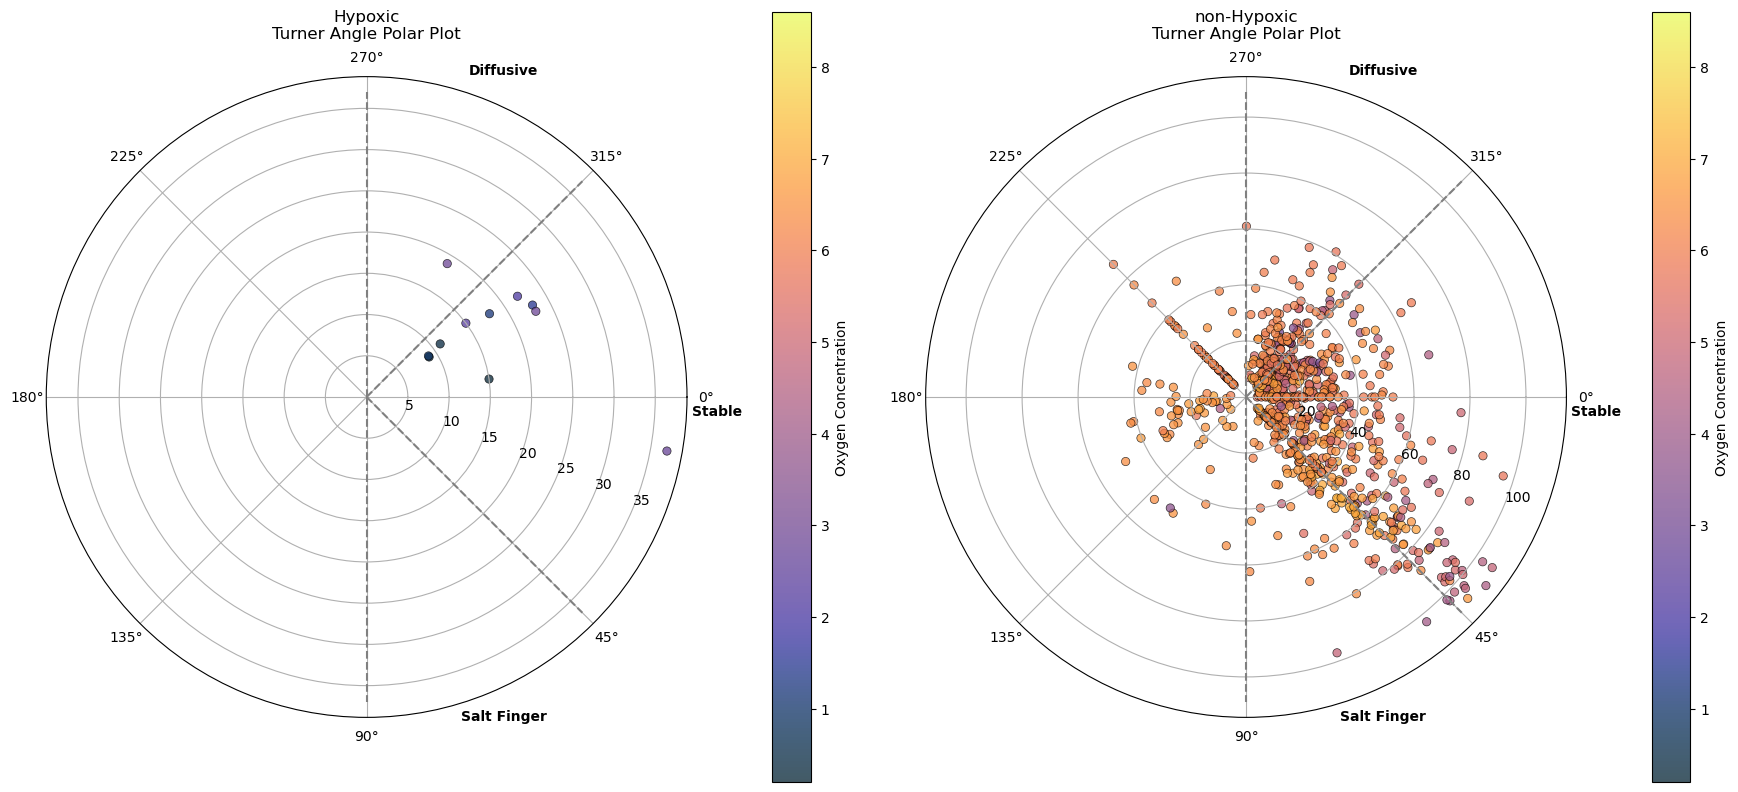

In [20]:
# Remove rows where 'tu' is NaN (e.g., the surface values we padded earlier)
plot_data = df_long.dropna(subset=['tu']).copy()
plot_data['tu_rad'] = np.radians(plot_data['tu'])

plot_data_h = plot_data[plot_data['oxy']<3] #rows of hypoxia
plot_data_nh= plot_data[plot_data['oxy']>=3] #rows of no hypoxia

data_list = [plot_data_h, plot_data_nh] 
titles = ["Hypoxic", "non-Hypoxic"]

all_oxy = pd.concat([d['oxy'] for d in data_list])
vmin, vmax = all_oxy.min(), all_oxy.max()

# 2. Create Figure with 2 Subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': 'polar'})
for ax, df, title in zip(axes, data_list, titles):
    sc = ax.scatter(x=df['tu_rad'], y=df['depth'], c=df['oxy'], cmap=cmo.thermal, alpha=0.75, edgecolors='k', linewidth=0.5, vmin=vmin, vmax=vmax)

    ax.set_theta_zero_location("E")  # 0 degrees at East (Right)
    ax.set_theta_direction(-1)       # Clockwise
    ax.set_title(f"{title}\nTurner Angle Polar Plot", va='bottom')
    max_d = df['depth'].max()
    ax.vlines(np.radians([45, 90, -45, -90]), 0, max_d, colors='gray', linestyles='--')
    ax.text(np.radians(3), max_d * 1.15, 'Stable', ha='center', fontweight='bold')
    ax.text(np.radians(67), max_d * 1.15, 'Salt Finger', ha='center', fontweight='bold')
    ax.text(np.radians(-67), max_d * 1.15, 'Diffusive', ha='center', fontweight='bold')
    cbar = plt.colorbar(sc, ax=ax, pad=0.1)
    cbar.set_label('Oxygen Concentration')
plt.tight_layout()
plt.show()

#when stable, no overturning. when Diffusive, still stable but cooler surface waters mix down the water-column and both temp and salinity increas with depth 
#when salt fingering, still stable but saltier surface waters are mixing down the water column. 
#when unstable overturning occurs 